<a href="https://colab.research.google.com/github/Hemant10HM/ANNDL-LAB_24mcs004/blob/main/ANN_Lab_1_DataLoader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt


# Define dataset path
dataset_path = "/content/drive/MyDrive/data/Pistachio_Image_Dataset"

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.125, 0.125, 0.125])
])

# Define custom dataset class
class PistachioDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        # Load images from "Kirmizi_Pistachio" folder (Class 0)
        kirmizi_folder = os.path.join(root_dir, "Kirmizi_Pistachio")
        for file in os.listdir(kirmizi_folder):
            if file.lower().endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(kirmizi_folder, file))
                self.labels.append(0)  # 0 for Kirmizi_Pistachio

        # Load images from "Siirt_Pistachio" folder (Class 1)
        siirt_folder = os.path.join(root_dir, "Siirt_Pistachio")
        for file in os.listdir(siirt_folder):
            if file.lower().endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(siirt_folder, file))
                self.labels.append(1)  # 1 for Siirt_Pistachio

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and label
        img_path = self.images[idx]
        label = self.labels[idx]

        # Open image
        image = Image.open(img_path).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.long)

        return image, label

# Instantiate dataset
dataset = PistachioDataset(dataset_path, transform=transform)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Test the DataLoader
for images, labels in dataloader:
    print(f"Batch size: {images.shape}, Labels: {labels}")
    break


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Batch size: torch.Size([64, 3, 256, 256]), Labels: tensor([0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1])


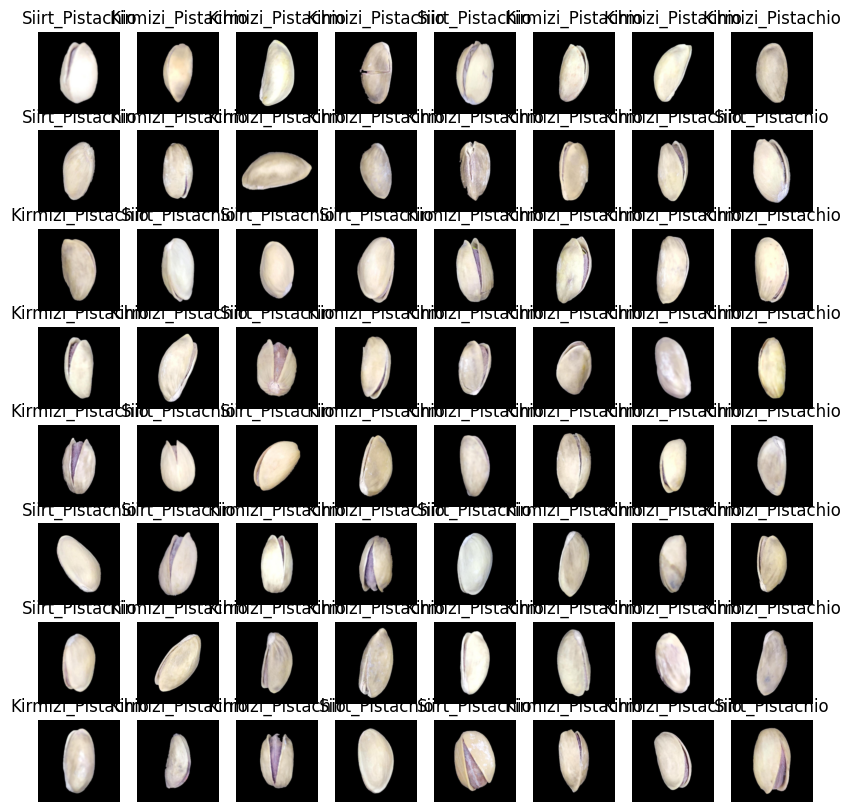

In [2]:
images, labels = next(iter(dataloader))

# Define Class Names
class_names = ["Kirmizi_Pistachio", "Siirt_Pistachio"]

# Plot the Images
plt.figure(figsize=(10, 10))

# Visualize 25 images (5x5 grid)
for i in range(64):
    plt.subplot(8, 8, i+1)
    img = images[i].permute(1, 2, 0)  # Change tensor shape from (C, H, W) -> (H, W, C)

    # Reverse normalization (optional)
    img = img * 0.125 + 0.5  # Because you normalized with mean=0.5 and std=0.125

    # Plot the image
    plt.imshow(img.numpy())
    plt.title(f"{class_names[labels[i].item()]}")
    plt.axis("off")

plt.show()

In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt


# Define dataset path
dataset_path = "/content/drive/MyDrive/data/Pistachio_Image_Dataset"

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.125])
])

# Define custom dataset class
class PistachioDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        # Load images from "Kirmizi_Pistachio" folder (Class 0)
        kirmizi_folder = os.path.join(root_dir, "Kirmizi_Pistachio")
        for file in os.listdir(kirmizi_folder):
            if file.lower().endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(kirmizi_folder, file))
                self.labels.append(0)  # 0 for Kirmizi_Pistachio

        # Load images from "Siirt_Pistachio" folder (Class 1)
        siirt_folder = os.path.join(root_dir, "Siirt_Pistachio")
        for file in os.listdir(siirt_folder):
            if file.lower().endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(siirt_folder, file))
                self.labels.append(1)  # 1 for Siirt_Pistachio

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and label
        img_path = self.images[idx]
        label = self.labels[idx]

        # Open image
        image = Image.open(img_path).convert("L")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.long)

        return image, label

# Instantiate dataset
dataset = PistachioDataset(dataset_path, transform=transform)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Test the DataLoader
for images, labels in dataloader:
    print(f"Batch size: {images.shape}, Labels: {labels}")
    break


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Batch size: torch.Size([64, 1, 256, 256]), Labels: tensor([0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
        0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
        1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1])


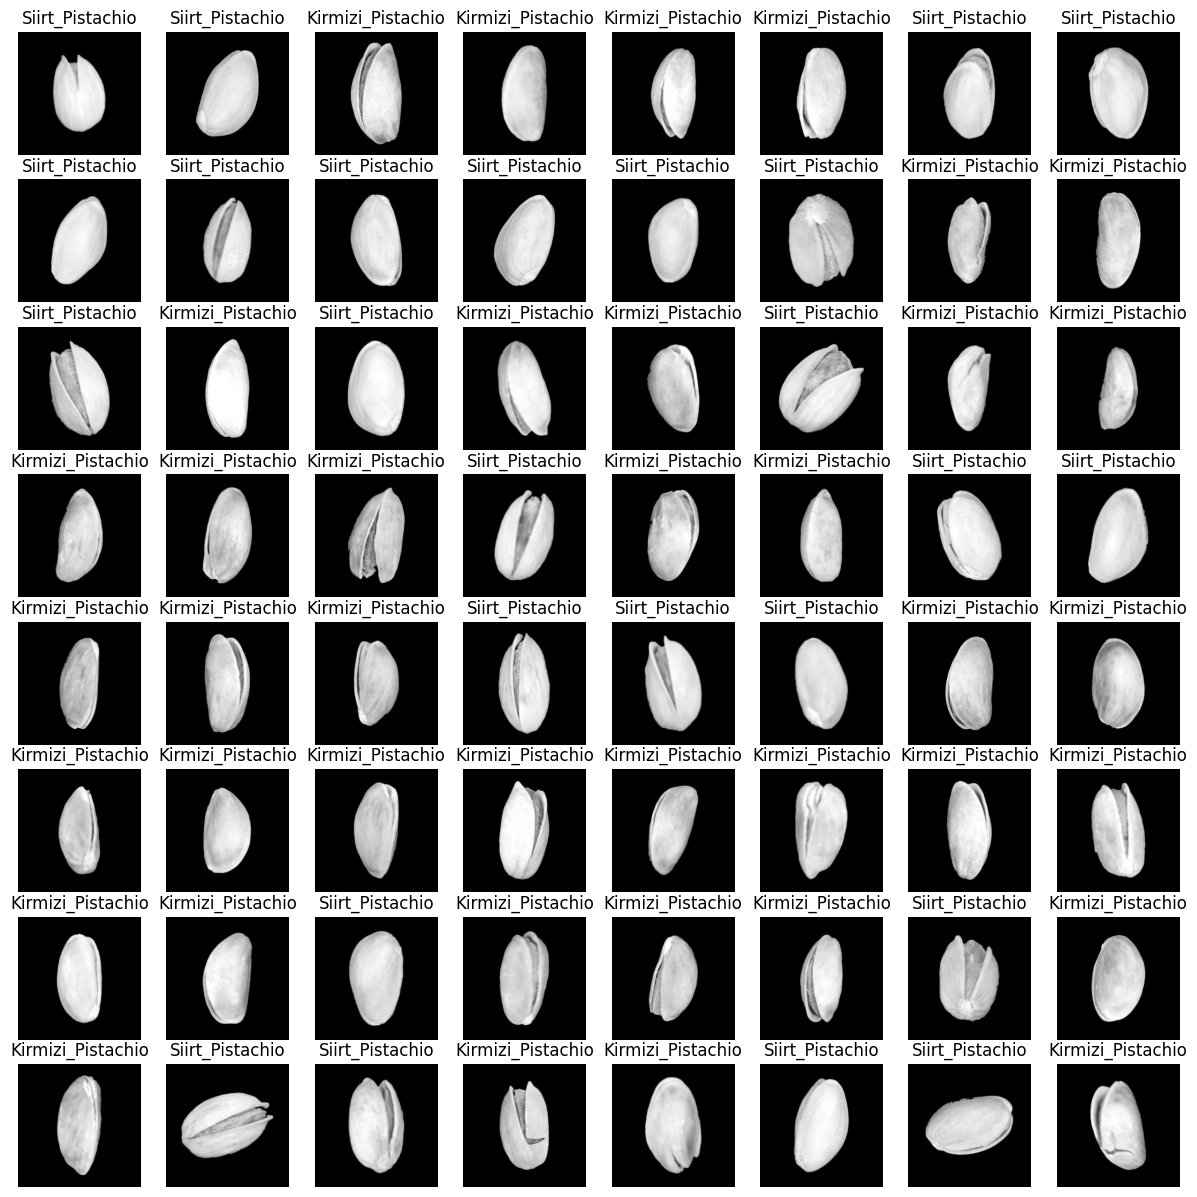

In [4]:
images, labels = next(iter(dataloader))

# Define Class Names
class_names = ["Kirmizi_Pistachio", "Siirt_Pistachio"]

# Plot the Images
plt.figure(figsize=(15, 15))

# Visualize  images (5x5 grid)
for i in range(64):
    plt.subplot(8, 8, i+1)
    img = images[i].permute(1, 2, 0)  # Change tensor shape from (C, H, W) -> (H, W, C)

    # Reverse normalization (optional)
    img = img * 0.125 + 0.5  # Because you normalized with mean=0.5 and std=0.125

    # Plot the image
    plt.imshow(img.numpy(),cmap="grey")
    plt.title(f"{class_names[labels[i].item()]}")
    plt.axis("off")

plt.show()